<a href="https://colab.research.google.com/github/JoelForson/ECON5200-Applied-Data-Analytics-in-Economics/blob/main/Lab%2014/Residual_Forensics%2C_The_White_Test%2C_and_Structural_Diagnostics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_white
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Ingestion and Naive Baseline Model
url = 'https://raw.githubusercontent.com/RyanPiao/ECON5200-Applied-Data-Analytics-in-Economics/refs/heads/main/Data/Nvidia_AI_Capex_Diagnostics_2026.csv'
df = pd.read_csv(url)

formula = 'AI_Software_Revenue ~ Hardware_Capex + Data_Center_Power_MW + Cloud_GPU_Deployments'
baseline_model = smf.ols(formula, data=df).fit()

print("--- NAIVE BASELINE OLS MODEL ---")
print(baseline_model.summary())

--- NAIVE BASELINE OLS MODEL ---
                             OLS Regression Results                            
Dep. Variable:     AI_Software_Revenue   R-squared:                       0.892
Model:                             OLS   Adj. R-squared:                  0.891
Method:                  Least Squares   F-statistic:                     676.4
Date:                 Tue, 17 Mar 2026   Prob (F-statistic):          1.77e-118
Time:                         17:58:13   Log-Likelihood:                -1591.3
No. Observations:                  250   AIC:                             3191.
Df Residuals:                      246   BIC:                             3205.
Df Model:                            3                                         
Covariance Type:             nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------

## Step 2: Visual Forensics of the Residuals
Extract the residual errors and the predicted fitted values. Utilize seaborn to plot the residuals on the Y-axis against the fitted values on the X-axis. Inspect the plot to see if the vertical spread of the residual errors remains constant or flares outward into a massive cone shape, indicating a "Pattern of Failure."

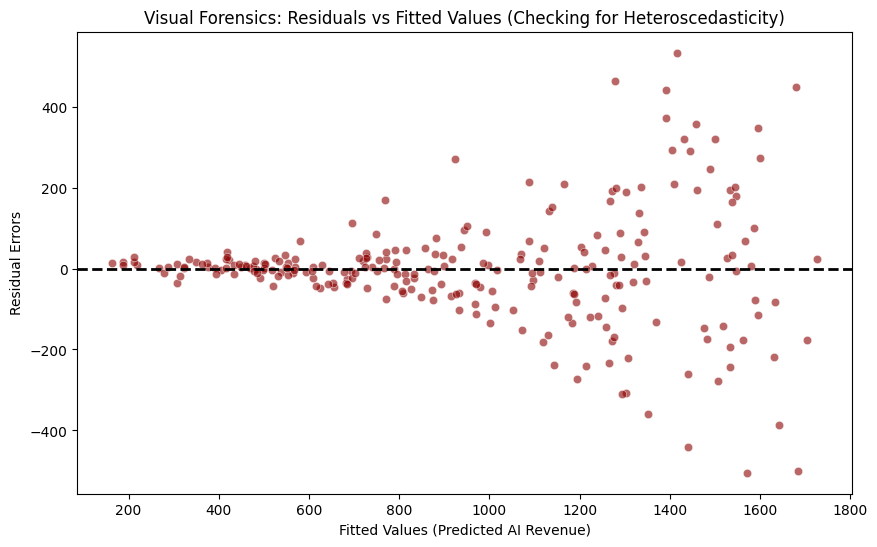

In [4]:
# Step 2: Visual Forensics
fitted_vals = baseline_model.fittedvalues
residuals = baseline_model.resid

plt.figure(figsize=(10, 6))
sns.scatterplot(x=fitted_vals, y=residuals, alpha=0.6, color='darkred')
plt.axhline(0, color='black', linestyle='--', linewidth=2)
plt.title('Visual Forensics: Residuals vs Fitted Values (Checking for Heteroscedasticity)')
plt.xlabel('Fitted Values (Predicted AI Revenue)')
plt.ylabel('Residual Errors')
plt.show()

## Step 3: Formalizing the Diagnosis (The White Test)
Visual forensics must be corroborated by rigorous mathematical testing. Execute the White Test by passing the model's residuals and the model's exact design matrix into the function to statistically confirm if variance is a function of the predictors.

In [7]:
# Step 3: The White Test Execution
# We must extract the design matrix generated by the formula interface
exog_matrix = baseline_model.model.exog

white_test_results = het_white(baseline_model.resid, exog_matrix)

labels = ['LM Statistic', 'LM-Test p-value', 'F-Statistic', 'F-Test p-value']
print("\n--- WHITE TEST RESULTS ---")
print(dict(zip(labels, white_test_results)))


--- WHITE TEST RESULTS ---
{'LM Statistic': np.float64(76.76209495636895), 'LM-Test p-value': np.float64(7.086616328807909e-13), 'F-Statistic': np.float64(11.816058375451716), 'F-Test p-value': np.float64(2.280234334373632e-15)}


## Step 4: Diagnosing Multicollinearity (Variance Inflation Factor)
Construct a Python for-loop to iterate through the columns of your design matrix and calculate the VIF for every explanatory variable to detect if redundant data is artificially inflating the variance of your coefficients.

In [10]:
# Step 4: Variance Inflation Factor (VIF) Loop
print("\n--- VARIANCE INFLATION FACTORS ---")

# Start loop at 1 to skip the constant intercept column at index 0
for i in range(1, exog_matrix.shape[1]):
    vif = variance_inflation_factor(exog_matrix, i)
    print(f"{baseline_model.model.exog_names[i]}: {vif:.2f}")


--- VARIANCE INFLATION FACTORS ---
Hardware_Capex: 18.19
Data_Center_Power_MW: 18.18
Cloud_GPU_Deployments: 1.00


## Step 5: The Mathematical Correction (HC3 Standard Errors)
Re-fit the exact same OLS formula from Step 1, but this time apply the Heteroscedasticity-Consistent (HC3) robust matrix correction to rescue the model and reveal the true, conservative statistical significance thresholds.

In [9]:
# Step 5: The Correction - HC3 Robust Standard Errors
robust_model = smf.ols(formula, data=df).fit(cov_type="HC3")

print("\n--- ROBUST OLS MODEL (HC3) ---")
print(robust_model.summary())


--- ROBUST OLS MODEL (HC3) ---
                             OLS Regression Results                            
Dep. Variable:     AI_Software_Revenue   R-squared:                       0.892
Model:                             OLS   Adj. R-squared:                  0.891
Method:                  Least Squares   F-statistic:                     460.1
Date:                 Tue, 17 Mar 2026   Prob (F-statistic):          1.50e-100
Time:                         18:12:19   Log-Likelihood:                -1591.3
No. Observations:                  250   AIC:                             3191.
Df Residuals:                      246   BIC:                             3205.
Df Model:                            3                                         
Covariance Type:                   HC3                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------

#AI-Assisted Expansion
-- Build an Interactive Diagnostic Dashboard
-- not actively working

In [15]:
!pip install streamlit

In [16]:
import streamlit as st
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan, het_white
from scipy import stats

# ─────────────────────────────────────────────────────────────────────────────
# PAGE CONFIG
# Must be the FIRST Streamlit call in the script. Sets the browser tab title,
# page layout (wide gives more horizontal real estate), and sidebar state.
# ─────────────────────────────────────────────────────────────────────────────
st.set_page_config(
    page_title="OLS Diagnostic Dashboard",
    page_icon="📊",
    layout="wide",
    initial_sidebar_state="expanded",
)

# ─────────────────────────────────────────────────────────────────────────────
# CUSTOM CSS
# st.markdown with unsafe_allow_html=True lets us inject raw CSS into the page.
# This overrides Streamlit's default theme for a cleaner, data-science aesthetic.
# ─────────────────────────────────────────────────────────────────────────────
st.markdown("""
<style>
    @import url('https://fonts.googleapis.com/css2?family=IBM+Plex+Mono:wght@400;600&family=IBM+Plex+Sans:wght@300;400;600&display=swap');

    /* Root variables for consistent theming */
    :root {
        --bg: #0f1117;
        --panel: #161b27;
        --border: #2a3347;
        --accent: #4f8ef7;
        --accent2: #f7c948;
        --success: #3ecf8e;
        --danger: #f26b6b;
        --text: #e0e6f0;
        --muted: #7a8499;
    }

    html, body, [class*="css"] {
        font-family: 'IBM Plex Sans', sans-serif;
        background-color: var(--bg);
        color: var(--text);
    }

    /* Sidebar */
    section[data-testid="stSidebar"] {
        background-color: var(--panel);
        border-right: 1px solid var(--border);
    }

    /* Metric cards */
    [data-testid="metric-container"] {
        background: var(--panel);
        border: 1px solid var(--border);
        border-radius: 8px;
        padding: 12px 16px;
    }

    /* Code / pre blocks (used by statsmodels summary) */
    pre {
        font-family: 'IBM Plex Mono', monospace !important;
        font-size: 12px !important;
        background: var(--panel) !important;
        border: 1px solid var(--border) !important;
        border-radius: 8px;
        padding: 16px !important;
        color: #c8d6f0 !important;
        overflow-x: auto;
    }

    /* Section headers */
    h2, h3 {
        font-family: 'IBM Plex Mono', monospace;
        letter-spacing: -0.5px;
    }

    /* Tab styling */
    .stTabs [data-baseweb="tab-list"] {
        gap: 4px;
        background: var(--panel);
        border-radius: 8px;
        padding: 4px;
        border: 1px solid var(--border);
    }
    .stTabs [data-baseweb="tab"] {
        font-family: 'IBM Plex Mono', monospace;
        font-size: 13px;
        color: var(--muted);
        border-radius: 6px;
    }
    .stTabs [aria-selected="true"] {
        background-color: var(--accent) !important;
        color: white !important;
    }

    /* Divider */
    hr { border-color: var(--border); }

    /* Pill badge */
    .badge {
        display: inline-block;
        padding: 2px 10px;
        border-radius: 20px;
        font-family: 'IBM Plex Mono', monospace;
        font-size: 11px;
        font-weight: 600;
    }
    .badge-green { background: #1a3d2e; color: #3ecf8e; border: 1px solid #3ecf8e44; }
    .badge-red   { background: #3d1a1a; color: #f26b6b; border: 1px solid #f26b6b44; }
    .badge-blue  { background: #1a2d4d; color: #4f8ef7; border: 1px solid #4f8ef744; }
</style>
""", unsafe_allow_html=True)


# ─────────────────────────────────────────────────────────────────────────────
# DATA GENERATION  ── @st.cache_data
#
# @st.cache_data caches the RETURN VALUE of this function keyed by its
# arguments. Streamlit re-runs the entire script on every widget interaction,
# so without caching, data would regenerate randomly on every click.
# The cache persists across reruns until the function arguments change or the
# cache is explicitly cleared.
# ─────────────────────────────────────────────────────────────────────────────
@st.cache_data
def generate_data(n: int, seed: int, heteroscedastic: bool, multicollinear: bool) -> pd.DataFrame:
    """
    Synthesise a dataset for OLS regression.

    Parameters
    ----------
    n               : number of observations
    seed            : random seed for reproducibility
    heteroscedastic : if True, error variance scales with X1 (violates Gauss-Markov)
    multicollinear  : if True, X2 is a near-linear combination of X1
    """
    rng = np.random.default_rng(seed)

    x1 = rng.normal(5, 2, n)                                        # Primary predictor
    x2 = (0.9 * x1 + rng.normal(0, 0.5, n)) if multicollinear \
         else rng.normal(3, 1.5, n)                                  # Correlated or independent
    x3 = rng.normal(10, 3, n)                                        # Always independent

    # Heteroscedastic errors: variance grows with X1
    if heteroscedastic:
        errors = rng.normal(0, np.abs(x1) * 0.6, n)
    else:
        errors = rng.normal(0, 2, n)

    y = 3 + 1.5 * x1 + 0.8 * x2 + 0.4 * x3 + errors

    return pd.DataFrame({"Y": y, "X1": x1, "X2": x2, "X3": x3})


# ─────────────────────────────────────────────────────────────────────────────
# MODEL FITTING  ── @st.cache_data
#
# Fitting is expensive for large n. Caching ensures we only refit when the
# underlying data (identified by its hash) actually changes.
# Returns both the naive OLS result AND the HC3 robust result from the same fit.
# ─────────────────────────────────────────────────────────────────────────────
@st.cache_data
def fit_models(df: pd.DataFrame):
    """
    Fit OLS and return naive + HC3-robust results.

    HC3 (MacKinnon–White) is the heteroscedasticity-robust covariance estimator
    recommended for small-to-moderate samples. It reweights squared residuals
    by (1 - h_ii)^2 where h_ii is the leverage of observation i.
    """
    X = sm.add_constant(df[["X1", "X2", "X3"]])   # Add intercept column
    y = df["Y"]

    ols_result    = sm.OLS(y, X).fit()             # Naive OLS
    robust_result = ols_result.get_robustcov_results(cov_type="HC3")  # Same betas, robust SEs

    return ols_result, robust_result


# ─────────────────────────────────────────────────────────────────────────────
# VIF COMPUTATION  ── @st.cache_data
#
# VIF for predictor j = 1 / (1 - R²_j), where R²_j is from regressing X_j
# on all other predictors. Cached separately because it only depends on X, not y.
# ─────────────────────────────────────────────────────────────────────────────
@st.cache_data
def compute_vif(df: pd.DataFrame) -> pd.DataFrame:
    """Return a DataFrame of VIF scores for each predictor."""
    X = df[["X1", "X2", "X3"]].values          # Raw matrix (no constant for VIF)
    cols = ["X1", "X2", "X3"]
    vifs = [variance_inflation_factor(X, i) for i in range(X.shape[1])]
    return pd.DataFrame({"Predictor": cols, "VIF": np.round(vifs, 3)})


# ─────────────────────────────────────────────────────────────────────────────
# DIAGNOSTIC TESTS  ── @st.cache_data
# ─────────────────────────────────────────────────────────────────────────────
@st.cache_data
def run_diagnostics(df: pd.DataFrame, _ols_result) -> dict:
    """
    Run Breusch-Pagan and White tests for heteroscedasticity.

    Breusch-Pagan: regresses squared residuals on X. Sensitive to linear
    heteroscedasticity. H0 = homoscedasticity.

    White's test: includes cross-products and squares. More general but loses
    degrees of freedom faster.
    """
    X = sm.add_constant(df[["X1", "X2", "X3"]])

    bp_lm, bp_p, bp_f, bp_fp = het_breuschpagan(_ols_result.resid, X)
    w_lm,  w_p,  w_f,  w_fp  = het_white(_ols_result.resid, X)

    # Shapiro-Wilk on residuals (normality)
    sw_stat, sw_p = stats.shapiro(_ols_result.resid)

    return {
        "bp_lm": bp_lm,   "bp_p": bp_p,
        "w_lm":  w_lm,    "w_p":  w_p,
        "sw_stat": sw_stat, "sw_p": sw_p,
    }


# ─────────────────────────────────────────────────────────────────────────────
# SIDEBAR  ── Streamlit widget area
#
# st.sidebar.* renders widgets in the collapsible left panel instead of
# the main content area. Widget return values are read as Python variables
# and automatically trigger a full script rerun when changed.
# ─────────────────────────────────────────────────────────────────────────────
with st.sidebar:
    st.markdown("## ⚙️ Model Configuration")
    st.markdown("---")

    # st.slider returns the current slider value each rerun.
    n_obs = st.slider(
        "Observations (n)",
        min_value=50, max_value=2000, value=300, step=50,
        help="More observations → more stable estimates and diagnostics."
    )

    seed = st.number_input(
        "Random Seed",
        min_value=0, max_value=9999, value=42, step=1,
        help="Change to explore different random samples with the same DGP."
    )

    st.markdown("### 🔧 Data Generating Process")

    # st.checkbox returns True/False. Each toggle is a widget state change
    # that causes Streamlit to rerun the script from top to bottom.
    heteroscedastic = st.checkbox(
        "Inject Heteroscedasticity",
        value=True,
        help="Error variance scales with |X1|. Violates Gauss-Markov assumption 4."
    )
    multicollinear = st.checkbox(
        "Inject Multicollinearity",
        value=True,
        help="X2 = 0.9·X1 + noise. Watch VIF scores spike."
    )

    st.markdown("---")
    st.markdown("### 📖 Quick Reference")
    st.markdown("""
| VIF | Verdict |
|-----|---------|
| 1–4 | ✅ Low |
| 4–10 | ⚠️ Moderate |
| >10 | 🚨 High |
    """)
    st.markdown("""
**HC3 Robust SEs** correct *inference* (t-stats, p-values) without changing
OLS point estimates. They do **not** fix efficiency loss from heteroscedasticity.
    """)

    st.markdown("---")
    st.caption("Built with Streamlit · Plotly · statsmodels")


# ─────────────────────────────────────────────────────────────────────────────
# MAIN CONTENT AREA
# ─────────────────────────────────────────────────────────────────────────────

# Dashboard header
st.markdown("# 📊 OLS Diagnostic Dashboard")
st.markdown(
    "Interactive regression diagnostics · heteroscedasticity · multicollinearity · residual analysis"
)
st.markdown("---")

# ── Load data and models (all cached) ────────────────────────────────────────
df              = generate_data(n_obs, seed, heteroscedastic, multicollinear)
ols_result, robust_result = fit_models(df)
vif_df          = compute_vif(df)
diagnostics     = run_diagnostics(df, ols_result)

# Residuals and fitted values for plotting
fitted    = ols_result.fittedvalues
residuals = ols_result.resid
std_resid = residuals / residuals.std()

# ── Top KPI row ──────────────────────────────────────────────────────────────
# st.columns(n) divides the row into n equal-width columns.
# Each column is a context manager; widgets inside render in that column.
kpi1, kpi2, kpi3, kpi4, kpi5 = st.columns(5)

with kpi1:
    st.metric("Observations", f"{n_obs:,}")
with kpi2:
    st.metric("R²", f"{ols_result.rsquared:.4f}")
with kpi3:
    st.metric("Adj. R²", f"{ols_result.rsquared_adj:.4f}")
with kpi4:
    # Color the F-stat p-value
    fp = ols_result.f_pvalue
    st.metric("F-stat p-value", f"{fp:.4f}", delta="Significant" if fp < 0.05 else "Not sig.")
with kpi5:
    st.metric("AIC", f"{ols_result.aic:.1f}")

st.markdown("---")

# ─────────────────────────────────────────────────────────────────────────────
# TABS
# st.tabs() creates a tabbed layout. Each tab is a context manager.
# Streamlit only renders the ACTIVE tab's content on each rerun.
# ─────────────────────────────────────────────────────────────────────────────
tab1, tab2, tab3, tab4 = st.tabs([
    "🔍 Residual Diagnostics",
    "📋 Model Summaries",
    "📐 VIF & Multicollinearity",
    "🧪 Statistical Tests",
])


# ── TAB 1: Residual Diagnostics ───────────────────────────────────────────────
with tab1:
    st.markdown("### Residual Diagnostic Plots")
    st.markdown(
        "These four plots are the **core toolkit** for OLS assumption checking. "
        "Use them together — no single plot tells the full story."
    )

    # 2×2 grid of plots using st.columns
    col_left, col_right = st.columns(2)

    # ── Plot 1: Residuals vs Fitted ───────────────────────────────────────────
    # Non-random patterns (fan, curve) → assumption violations
    with col_left:
        fig1 = px.scatter(
            x=fitted, y=residuals,
            labels={"x": "Fitted Values", "y": "Residuals"},
            title="Residuals vs. Fitted",
            opacity=0.55,
            color=np.abs(residuals),              # Color by magnitude of residual
            color_continuous_scale="Blues",
        )
        fig1.add_hline(y=0, line_dash="dash", line_color="#f7c948", line_width=1.5)
        fig1.update_layout(
            plot_bgcolor="#161b27", paper_bgcolor="#0f1117",
            font_color="#e0e6f0", coloraxis_showscale=False,
            title_font_family="IBM Plex Mono",
        )
        st.plotly_chart(fig1, use_container_width=True)
        st.caption(
            "**What to look for:** A random horizontal scatter around zero → ✅ homoscedasticity. "
            "A fan/cone shape → 🚨 heteroscedasticity."
        )

    # ── Plot 2: Scale-Location (√|Standardised Residuals| vs Fitted) ─────────
    # Linearises the fan pattern for easier detection
    with col_right:
        sqrt_abs_std = np.sqrt(np.abs(std_resid))
        fig2 = px.scatter(
            x=fitted, y=sqrt_abs_std,
            labels={"x": "Fitted Values", "y": "√|Standardised Residuals|"},
            title="Scale–Location",
            opacity=0.55,
            color=sqrt_abs_std,
            color_continuous_scale="Reds",
        )
        # Lowess smoothing line to visualise trend
        lowess = sm.nonparametric.lowess(sqrt_abs_std, fitted, frac=0.3)
        fig2.add_scatter(
            x=lowess[:, 0], y=lowess[:, 1],
            mode="lines", line=dict(color="#f26b6b", width=2.5),
            name="LOWESS"
        )
        fig2.update_layout(
            plot_bgcolor="#161b27", paper_bgcolor="#0f1117",
            font_color="#e0e6f0", coloraxis_showscale=False,
            title_font_family="IBM Plex Mono",
        )
        st.plotly_chart(fig2, use_container_width=True)
        st.caption(
            "**What to look for:** A flat red LOWESS line → ✅ homoscedasticity. "
            "A rising line → variance grows with fitted values → 🚨 heteroscedasticity."
        )

    col_left2, col_right2 = st.columns(2)

    # ── Plot 3: Q-Q Plot (Normality of Residuals) ────────────────────────────
    with col_left2:
        (osm, osr), (slope, intercept, _) = stats.probplot(residuals)
        qq_theoretical = np.array(osm)
        qq_sample      = np.array(osr)

        fig3 = go.Figure()
        fig3.add_scatter(
            x=qq_theoretical, y=qq_sample,
            mode="markers", marker=dict(color="#4f8ef7", opacity=0.6, size=5),
            name="Residuals"
        )
        # Reference line: perfect normality
        line_x = [qq_theoretical.min(), qq_theoretical.max()]
        line_y = [slope * x + intercept for x in line_x]
        fig3.add_scatter(
            x=line_x, y=line_y,
            mode="lines", line=dict(color="#f7c948", dash="dash", width=2),
            name="Normal ref."
        )
        fig3.update_layout(
            title="Normal Q-Q Plot",
            xaxis_title="Theoretical Quantiles",
            yaxis_title="Sample Quantiles",
            plot_bgcolor="#161b27", paper_bgcolor="#0f1117",
            font_color="#e0e6f0", title_font_family="IBM Plex Mono",
        )
        st.plotly_chart(fig3, use_container_width=True)
        st.caption(
            "**What to look for:** Points hugging the dashed line → ✅ normal residuals. "
            "S-curves or heavy tails → departure from normality."
        )

    # ── Plot 4: Residuals vs X1 (specific predictor check) ───────────────────
    with col_right2:
        fig4 = px.scatter(
            x=df["X1"], y=residuals,
            labels={"x": "X1", "y": "Residuals"},
            title="Residuals vs. X1",
            opacity=0.55,
            color=np.abs(residuals),
            color_continuous_scale="Purples",
        )
        fig4.add_hline(y=0, line_dash="dash", line_color="#f7c948", line_width=1.5)
        fig4.update_layout(
            plot_bgcolor="#161b27", paper_bgcolor="#0f1117",
            font_color="#e0e6f0", coloraxis_showscale=False,
            title_font_family="IBM Plex Mono",
        )
        st.plotly_chart(fig4, use_container_width=True)
        st.caption(
            "**What to look for:** Since error variance scales with |X1| when heteroscedasticity "
            "is injected, a funnel shape here directly implicates X1 as the source."
        )


# ── TAB 2: Model Summaries ────────────────────────────────────────────────────
with tab2:
    st.markdown("### OLS Model Summary")
    st.markdown(
        "Toggle between the **Naive OLS** summary (assumes homoscedasticity) and the "
        "**HC3 Robust** summary (corrects standard errors for heteroscedasticity). "
        "Point estimates (coefficients) are identical — only inference changes."
    )

    # st.radio renders a horizontal button group. The returned string is the
    # selected label. This controls which summary is displayed below.
    summary_choice = st.radio(
        "Select Summary Type",
        options=["Naive OLS", "HC3 Robust (Heteroscedasticity-Consistent)"],
        horizontal=True,
    )

    if summary_choice == "Naive OLS":
        st.markdown(
            "⚠️ **Naive OLS** standard errors are only valid under homoscedasticity. "
            "If the residual plots show a fan shape, t-stats and p-values here are unreliable."
        )
        st.code(str(ols_result.summary()), language=None)
    else:
        st.markdown(
            "✅ **HC3 Robust** SEs (MacKinnon–White 1985) are consistent under "
            "heteroscedasticity of unknown form. Safe to use when in doubt."
        )
        st.code(str(robust_result.summary()), language=None)

    # Side-by-side coefficient comparison
    st.markdown("---")
    st.markdown("### Coefficient Comparison: Naive vs. Robust SEs")

    coef_df = pd.DataFrame({
        "Predictor":   ols_result.params.index,
        "Coefficient": np.round(ols_result.params, 4),
        "SE (Naive)":  np.round(ols_result.bse, 4),
        "SE (HC3)":    np.round(robust_result.bse, 4),
        "t (Naive)":   np.round(ols_result.tvalues, 3),
        "t (HC3)":     np.round(robust_result.tvalues, 3),
        "p (Naive)":   np.round(ols_result.pvalues, 4),
        "p (HC3)":     np.round(robust_result.pvalues, 4),
    })

    # Plotly grouped bar: SE comparison
    fig_se = go.Figure()
    fig_se.add_bar(
        x=coef_df["Predictor"], y=coef_df["SE (Naive)"],
        name="Naive SE", marker_color="#4f8ef7"
    )
    fig_se.add_bar(
        x=coef_df["Predictor"], y=coef_df["SE (HC3)"],
        name="HC3 SE", marker_color="#f26b6b"
    )
    fig_se.update_layout(
        barmode="group",
        title="Standard Error: Naive vs. HC3",
        xaxis_title="Predictor",
        yaxis_title="Standard Error",
        plot_bgcolor="#161b27", paper_bgcolor="#0f1117",
        font_color="#e0e6f0", title_font_family="IBM Plex Mono",
        legend=dict(orientation="h", yanchor="bottom", y=1.02),
    )
    st.plotly_chart(fig_se, use_container_width=True)
    st.caption(
        "Large gaps between bars indicate that heteroscedasticity is materially distorting "
        "inference. HC3 SEs are typically larger (more conservative) when variance is non-constant."
    )


# ── TAB 3: VIF & Multicollinearity ───────────────────────────────────────────
with tab3:
    st.markdown("### Variance Inflation Factor (VIF)")
    st.markdown(
        "VIF quantifies how much the variance of a coefficient is *inflated* due to "
        "correlations with other predictors. **VIF = 1/(1 − R²ⱼ)** where R²ⱼ is from "
        "regressing Xⱼ on all other predictors."
    )

    # Dynamic colour: green / orange / red based on VIF thresholds
    def vif_color(v):
        if v < 4:   return "#3ecf8e"
        if v < 10:  return "#f7c948"
        return "#f26b6b"

    vif_colors = [vif_color(v) for v in vif_df["VIF"]]

    fig_vif = go.Figure(go.Bar(
        x=vif_df["Predictor"],
        y=vif_df["VIF"],
        marker_color=vif_colors,
        text=vif_df["VIF"].apply(lambda v: f"{v:.2f}"),
        textposition="outside",
    ))
    fig_vif.add_hline(y=4,  line_dash="dot", line_color="#f7c948", annotation_text="Moderate (4)",  annotation_position="right")
    fig_vif.add_hline(y=10, line_dash="dot", line_color="#f26b6b", annotation_text="High (10)",     annotation_position="right")
    fig_vif.update_layout(
        title="VIF Scores by Predictor",
        xaxis_title="Predictor",
        yaxis_title="VIF",
        plot_bgcolor="#161b27", paper_bgcolor="#0f1117",
        font_color="#e0e6f0", title_font_family="IBM Plex Mono",
        yaxis=dict(range=[0, max(vif_df["VIF"].max() * 1.25, 12)]),
    )
    st.plotly_chart(fig_vif, use_container_width=True)

    # VIF table with conditional formatting via pandas Styler
    st.markdown("#### VIF Table")

    def highlight_vif(val):
        if val > 10:  return "background-color: #3d1a1a; color: #f26b6b"
        if val > 4:   return "background-color: #3d3314; color: #f7c948"
        return "background-color: #1a3d2e; color: #3ecf8e"

    styled = vif_df.style.applymap(highlight_vif, subset=["VIF"])
    st.dataframe(styled, use_container_width=True, hide_index=True)

    st.markdown("---")
    st.markdown("### Correlation Matrix (Predictors)")

    corr = df[["X1", "X2", "X3"]].corr()

    fig_corr = px.imshow(
        corr,
        text_auto=".3f",
        color_continuous_scale="RdBu_r",
        zmin=-1, zmax=1,
        title="Predictor Correlation Matrix",
    )
    fig_corr.update_layout(
        plot_bgcolor="#161b27", paper_bgcolor="#0f1117",
        font_color="#e0e6f0", title_font_family="IBM Plex Mono",
    )
    st.plotly_chart(fig_corr, use_container_width=True)
    st.caption(
        "Correlation alone doesn't fully capture multicollinearity (three-way collinearity "
        "can exist with low pairwise correlations). Always cross-reference with VIF scores."
    )


# ── TAB 4: Statistical Tests ──────────────────────────────────────────────────
with tab4:
    st.markdown("### Formal Diagnostic Tests")

    def sig_badge(p: float) -> str:
        """Return an HTML badge indicating statistical significance."""
        if p < 0.01:  return '<span class="badge badge-red">p &lt; 0.01 🚨</span>'
        if p < 0.05:  return '<span class="badge badge-red">p &lt; 0.05 ⚠️</span>'
        return '<span class="badge badge-green">p ≥ 0.05 ✅</span>'

    col_t1, col_t2 = st.columns(2)

    # Breusch-Pagan
    with col_t1:
        st.markdown("#### 🔬 Breusch-Pagan Test")
        st.markdown("**H₀:** Homoscedasticity (constant error variance)")
        st.markdown(f"LM Statistic: **{diagnostics['bp_lm']:.4f}**")
        st.markdown(f"p-value: **{diagnostics['bp_p']:.4f}** {sig_badge(diagnostics['bp_p'])}",
                    unsafe_allow_html=True)
        if diagnostics["bp_p"] < 0.05:
            st.error("Reject H₀ → Evidence of heteroscedasticity. Consider HC3 robust SEs.")
        else:
            st.success("Fail to reject H₀ → No strong evidence of heteroscedasticity.")

    # White's Test
    with col_t2:
        st.markdown("#### 🔬 White's Test")
        st.markdown("**H₀:** Homoscedasticity (includes interaction terms)")
        st.markdown(f"LM Statistic: **{diagnostics['w_lm']:.4f}**")
        st.markdown(f"p-value: **{diagnostics['w_p']:.4f}** {sig_badge(diagnostics['w_p'])}",
                    unsafe_allow_html=True)
        if diagnostics["w_p"] < 0.05:
            st.error("Reject H₀ → Evidence of heteroscedasticity (general form).")
        else:
            st.success("Fail to reject H₀ → No strong evidence of heteroscedasticity.")

    st.markdown("---")

    # Shapiro-Wilk
    st.markdown("#### 🔬 Shapiro-Wilk Test (Residual Normality)")
    st.markdown("**H₀:** Residuals are normally distributed")

    col_sw1, col_sw2 = st.columns([1, 3])
    with col_sw1:
        st.metric("W Statistic", f"{diagnostics['sw_stat']:.4f}")
        st.metric("p-value", f"{diagnostics['sw_p']:.4f}")
    with col_sw2:
        st.markdown(f"{sig_badge(diagnostics['sw_p'])}", unsafe_allow_html=True)
        if diagnostics["sw_p"] < 0.05:
            st.warning(
                "Reject H₀ → Residuals deviate from normality. "
                "OLS is still BLUE (Gauss-Markov doesn't require normality), but "
                "finite-sample inference (t-tests, F-tests) relies on it."
            )
        else:
            st.success("Fail to reject H₀ → Residuals appear normally distributed.")

    st.markdown("---")
    st.markdown("### 📊 Test Results at a Glance")

    # Summary table
    summary_tests = pd.DataFrame({
        "Test": ["Breusch-Pagan", "White's Test", "Shapiro-Wilk"],
        "Null Hypothesis": [
            "Homoscedasticity",
            "Homoscedasticity (general)",
            "Residuals ~ Normal",
        ],
        "Statistic": [
            round(diagnostics["bp_lm"], 4),
            round(diagnostics["w_lm"], 4),
            round(diagnostics["sw_stat"], 4),
        ],
        "p-value": [
            round(diagnostics["bp_p"], 4),
            round(diagnostics["w_p"], 4),
            round(diagnostics["sw_p"], 4),
        ],
        "Decision (α=0.05)": [
            "Reject H₀" if diagnostics["bp_p"] < 0.05 else "Fail to Reject",
            "Reject H₀" if diagnostics["w_p"]  < 0.05 else "Fail to Reject",
            "Reject H₀" if diagnostics["sw_p"] < 0.05 else "Fail to Reject",
        ]
    })
    st.dataframe(summary_tests, use_container_width=True, hide_index=True)


# ─────────────────────────────────────────────────────────────────────────────
# FOOTER
# ─────────────────────────────────────────────────────────────────────────────
st.markdown("---")
st.markdown(
    "<p style='text-align:center; color:#7a8499; font-family:IBM Plex Mono, monospace; font-size:12px'>"
    "OLS Diagnostic Dashboard · Built with Streamlit + Plotly + statsmodels"
    "</p>",
    unsafe_allow_html=True,
)

2026-03-17 18:22:55.846 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-17 18:22:55.850 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-17 18:22:55.852 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-17 18:22:55.855 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-17 18:22:55.860 No runtime found, using MemoryCacheStorageManager
2026-03-17 18:22:55.866 No runtime found, using MemoryCacheStorageManager
2026-03-17 18:22:55.871 No runtime found, using MemoryCacheStorageManager
2026-03-17 18:22:55.876 No runtime found, using MemoryCacheStorageManager
2026-03-17 18:22:55.882 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-17 18:22:55.886 Thread 'MainThread': missing ScriptRunContext! Thi

DeltaGenerator()

In [17]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan, het_white
from scipy import stats

# ─────────────────────────────────────────────────────────────────────────────
# PAGE CONFIG
# Must be the FIRST Streamlit call in the script. Sets the browser tab title,
# page layout (wide gives more horizontal real estate), and sidebar state.
# ─────────────────────────────────────────────────────────────────────────────
st.set_page_config(
    page_title="OLS Diagnostic Dashboard",
    page_icon="📊",
    layout="wide",
    initial_sidebar_state="expanded",
)

# ─────────────────────────────────────────────────────────────────────────────
# CUSTOM CSS
# st.markdown with unsafe_allow_html=True lets us inject raw CSS into the page.
# This overrides Streamlit's default theme for a cleaner, data-science aesthetic.
# ─────────────────────────────────────────────────────────────────────────────
st.markdown("""
<style>
    @import url('https://fonts.googleapis.com/css2?family=IBM+Plex+Mono:wght@400;600&family=IBM+Plex+Sans:wght@300;400;600&display=swap');

    /* Root variables for consistent theming */
    :root {
        --bg: #0f1117;
        --panel: #161b27;
        --border: #2a3347;
        --accent: #4f8ef7;
        --accent2: #f7c948;
        --success: #3ecf8e;
        --danger: #f26b6b;
        --text: #e0e6f0;
        --muted: #7a8499;
    }

    html, body, [class*="css"] {
        font-family: 'IBM Plex Sans', sans-serif;
        background-color: var(--bg);
        color: var(--text);
    }

    /* Sidebar */
    section[data-testid="stSidebar"] {
        background-color: var(--panel);
        border-right: 1px solid var(--border);
    }

    /* Metric cards */
    [data-testid="metric-container"] {
        background: var(--panel);
        border: 1px solid var(--border);
        border-radius: 8px;
        padding: 12px 16px;
    }

    /* Code / pre blocks (used by statsmodels summary) */
    pre {
        font-family: 'IBM Plex Mono', monospace !important;
        font-size: 12px !important;
        background: var(--panel) !important;
        border: 1px solid var(--border) !important;
        border-radius: 8px;
        padding: 16px !important;
        color: #c8d6f0 !important;
        overflow-x: auto;
    }

    /* Section headers */
    h2, h3 {
        font-family: 'IBM Plex Mono', monospace;
        letter-spacing: -0.5px;
    }

    /* Tab styling */
    .stTabs [data-baseweb="tab-list"] {
        gap: 4px;
        background: var(--panel);
        border-radius: 8px;
        padding: 4px;
        border: 1px solid var(--border);
    }
    .stTabs [data-baseweb="tab"] {
        font-family: 'IBM Plex Mono', monospace;
        font-size: 13px;
        color: var(--muted);
        border-radius: 6px;
    }
    .stTabs [aria-selected="true"] {
        background-color: var(--accent) !important;
        color: white !important;
    }

    /* Divider */
    hr { border-color: var(--border); }

    /* Pill badge */
    .badge {
        display: inline-block;
        padding: 2px 10px;
        border-radius: 20px;
        font-family: 'IBM Plex Mono', monospace;
        font-size: 11px;
        font-weight: 600;
    }
    .badge-green { background: #1a3d2e; color: #3ecf8e; border: 1px solid #3ecf8e44; }
    .badge-red   { background: #3d1a1a; color: #f26b6b; border: 1px solid #f26b6b44; }
    .badge-blue  { background: #1a2d4d; color: #4f8ef7; border: 1px solid #4f8ef744; }
</style>
""", unsafe_allow_html=True)


# ─────────────────────────────────────────────────────────────────────────────
# DATA GENERATION  ── @st.cache_data
#
# @st.cache_data caches the RETURN VALUE of this function keyed by its
# arguments. Streamlit re-runs the entire script on every widget interaction,
# so without caching, data would regenerate randomly on every click.
# The cache persists across reruns until the function arguments change or the
# cache is explicitly cleared.
# ─────────────────────────────────────────────────────────────────────────────
@st.cache_data
def generate_data(n: int, seed: int, heteroscedastic: bool, multicollinear: bool) -> pd.DataFrame:
    """
    Synthesise a dataset for OLS regression.

    Parameters
    ----------
    n               : number of observations
    seed            : random seed for reproducibility
    heteroscedastic : if True, error variance scales with X1 (violates Gauss-Markov)
    multicollinear  : if True, X2 is a near-linear combination of X1
    """
    rng = np.random.default_rng(seed)

    x1 = rng.normal(5, 2, n)                                        # Primary predictor
    x2 = (0.9 * x1 + rng.normal(0, 0.5, n)) if multicollinear \
         else rng.normal(3, 1.5, n)                                  # Correlated or independent
    x3 = rng.normal(10, 3, n)                                        # Always independent

    # Heteroscedastic errors: variance grows with X1
    if heteroscedastic:
        errors = rng.normal(0, np.abs(x1) * 0.6, n)
    else:
        errors = rng.normal(0, 2, n)

    y = 3 + 1.5 * x1 + 0.8 * x2 + 0.4 * x3 + errors

    return pd.DataFrame({"Y": y, "X1": x1, "X2": x2, "X3": x3})


# ─────────────────────────────────────────────────────────────────────────────
# MODEL FITTING  ── @st.cache_data
#
# Fitting is expensive for large n. Caching ensures we only refit when the
# underlying data (identified by its hash) actually changes.
# Returns both the naive OLS result AND the HC3 robust result from the same fit.
# ─────────────────────────────────────────────────────────────────────────────
@st.cache_data
def fit_models(df: pd.DataFrame):
    """
    Fit OLS and return naive + HC3-robust results.

    HC3 (MacKinnon–White) is the heteroscedasticity-robust covariance estimator
    recommended for small-to-moderate samples. It reweights squared residuals
    by (1 - h_ii)^2 where h_ii is the leverage of observation i.
    """
    X = sm.add_constant(df[["X1", "X2", "X3"]])   # Add intercept column
    y = df["Y"]

    ols_result    = sm.OLS(y, X).fit()             # Naive OLS
    robust_result = ols_result.get_robustcov_results(cov_type="HC3")  # Same betas, robust SEs

    return ols_result, robust_result


# ─────────────────────────────────────────────────────────────────────────────
# VIF COMPUTATION  ── @st.cache_data
#
# VIF for predictor j = 1 / (1 - R²_j), where R²_j is from regressing X_j
# on all other predictors. Cached separately because it only depends on X, not y.
# ─────────────────────────────────────────────────────────────────────────────
@st.cache_data
def compute_vif(df: pd.DataFrame) -> pd.DataFrame:
    """Return a DataFrame of VIF scores for each predictor."""
    X = df[["X1", "X2", "X3"]].values          # Raw matrix (no constant for VIF)
    cols = ["X1", "X2", "X3"]
    vifs = [variance_inflation_factor(X, i) for i in range(X.shape[1])]
    return pd.DataFrame({"Predictor": cols, "VIF": np.round(vifs, 3)})


# ─────────────────────────────────────────────────────────────────────────────
# DIAGNOSTIC TESTS  ── @st.cache_data
# ─────────────────────────────────────────────────────────────────────────────
@st.cache_data
def run_diagnostics(df: pd.DataFrame, _ols_result) -> dict:
    """
    Run Breusch-Pagan and White tests for heteroscedasticity.

    Breusch-Pagan: regresses squared residuals on X. Sensitive to linear
    heteroscedasticity. H0 = homoscedasticity.

    White's test: includes cross-products and squares. More general but loses
    degrees of freedom faster.
    """
    X = sm.add_constant(df[["X1", "X2", "X3"]])

    bp_lm, bp_p, bp_f, bp_fp = het_breuschpagan(_ols_result.resid, X)
    w_lm,  w_p,  w_f,  w_fp  = het_white(_ols_result.resid, X)

    # Shapiro-Wilk on residuals (normality)
    sw_stat, sw_p = stats.shapiro(_ols_result.resid)

    return {
        "bp_lm": bp_lm,   "bp_p": bp_p,
        "w_lm":  w_lm,    "w_p":  w_p,
        "sw_stat": sw_stat, "sw_p": sw_p,
    }


# ─────────────────────────────────────────────────────────────────────────────
# SIDEBAR  ── Streamlit widget area
#
# st.sidebar.* renders widgets in the collapsible left panel instead of
# the main content area. Widget return values are read as Python variables
# and automatically trigger a full script rerun when changed.
# ─────────────────────────────────────────────────────────────────────────────
with st.sidebar:
    st.markdown("## ⚙️ Model Configuration")
    st.markdown("---")

    # st.slider returns the current slider value each rerun.
    n_obs = st.slider(
        "Observations (n)",
        min_value=50, max_value=2000, value=300, step=50,
        help="More observations → more stable estimates and diagnostics."
    )

    seed = st.number_input(
        "Random Seed",
        min_value=0, max_value=9999, value=42, step=1,
        help="Change to explore different random samples with the same DGP."
    )

    st.markdown("### 🔧 Data Generating Process")

    # st.checkbox returns True/False. Each toggle is a widget state change
    # that causes Streamlit to rerun the script from top to bottom.
    heteroscedastic = st.checkbox(
        "Inject Heteroscedasticity",
        value=True,
        help="Error variance scales with |X1|. Violates Gauss-Markov assumption 4."
    )
    multicollinear = st.checkbox(
        "Inject Multicollinearity",
        value=True,
        help="X2 = 0.9·X1 + noise. Watch VIF scores spike."
    )

    st.markdown("---")
    st.markdown("### 📖 Quick Reference")
    st.markdown("""
| VIF | Verdict |
|-----|---------|
| 1–4 | ✅ Low |
| 4–10 | ⚠️ Moderate |
| >10 | 🚨 High |
    """)
    st.markdown("""
**HC3 Robust SEs** correct *inference* (t-stats, p-values) without changing
OLS point estimates. They do **not** fix efficiency loss from heteroscedasticity.
    """)

    st.markdown("---")
    st.caption("Built with Streamlit · Plotly · statsmodels")


# ─────────────────────────────────────────────────────────────────────────────
# MAIN CONTENT AREA
# ─────────────────────────────────────────────────────────────────────────────

# Dashboard header
st.markdown("# 📊 OLS Diagnostic Dashboard")
st.markdown(
    "Interactive regression diagnostics · heteroscedasticity · multicollinearity · residual analysis"
)
st.markdown("---")

# ── Load data and models (all cached) ────────────────────────────────────────
df              = generate_data(n_obs, seed, heteroscedastic, multicollinear)
ols_result, robust_result = fit_models(df)
vif_df          = compute_vif(df)
diagnostics     = run_diagnostics(df, ols_result)

# Residuals and fitted values for plotting
fitted    = ols_result.fittedvalues
residuals = ols_result.resid
std_resid = residuals / residuals.std()

# ── Top KPI row ──────────────────────────────────────────────────────────────
# st.columns(n) divides the row into n equal-width columns.
# Each column is a context manager; widgets inside render in that column.
kpi1, kpi2, kpi3, kpi4, kpi5 = st.columns(5)

with kpi1:
    st.metric("Observations", f"{n_obs:,}")
with kpi2:
    st.metric("R²", f"{ols_result.rsquared:.4f}")
with kpi3:
    st.metric("Adj. R²", f"{ols_result.rsquared_adj:.4f}")
with kpi4:
    # Color the F-stat p-value
    fp = ols_result.f_pvalue
    st.metric("F-stat p-value", f"{fp:.4f}", delta="Significant" if fp < 0.05 else "Not sig.")
with kpi5:
    st.metric("AIC", f"{ols_result.aic:.1f}")

st.markdown("---")

# ─────────────────────────────────────────────────────────────────────────────
# TABS
# st.tabs() creates a tabbed layout. Each tab is a context manager.
# Streamlit only renders the ACTIVE tab's content on each rerun.
# ─────────────────────────────────────────────────────────────────────────────
tab1, tab2, tab3, tab4 = st.tabs([
    "🔍 Residual Diagnostics",
    "📋 Model Summaries",
    "📐 VIF & Multicollinearity",
    "🧪 Statistical Tests",
])


# ── TAB 1: Residual Diagnostics ───────────────────────────────────────────────
with tab1:
    st.markdown("### Residual Diagnostic Plots")
    st.markdown(
        "These four plots are the **core toolkit** for OLS assumption checking. "
        "Use them together — no single plot tells the full story."
    )

    # 2×2 grid of plots using st.columns
    col_left, col_right = st.columns(2)

    # ── Plot 1: Residuals vs Fitted ───────────────────────────────────────────
    # Non-random patterns (fan, curve) → assumption violations
    with col_left:
        fig1 = px.scatter(
            x=fitted, y=residuals,
            labels={"x": "Fitted Values", "y": "Residuals"},
            title="Residuals vs. Fitted",
            opacity=0.55,
            color=np.abs(residuals),              # Color by magnitude of residual
            color_continuous_scale="Blues",
        )
        fig1.add_hline(y=0, line_dash="dash", line_color="#f7c948", line_width=1.5)
        fig1.update_layout(
            plot_bgcolor="#161b27", paper_bgcolor="#0f1117",
            font_color="#e0e6f0", coloraxis_showscale=False,
            title_font_family="IBM Plex Mono",
        )
        st.plotly_chart(fig1, use_container_width=True)
        st.caption(
            "**What to look for:** A random horizontal scatter around zero → ✅ homoscedasticity. "
            "A fan/cone shape → 🚨 heteroscedasticity."
        )

    # ── Plot 2: Scale-Location (√|Standardised Residuals| vs Fitted) ─────────
    # Linearises the fan pattern for easier detection
    with col_right:
        sqrt_abs_std = np.sqrt(np.abs(std_resid))
        fig2 = px.scatter(
            x=fitted, y=sqrt_abs_std,
            labels={"x": "Fitted Values", "y": "√|Standardised Residuals|"},
            title="Scale–Location",
            opacity=0.55,
            color=sqrt_abs_std,
            color_continuous_scale="Reds",
        )
        # Lowess smoothing line to visualise trend
        lowess = sm.nonparametric.lowess(sqrt_abs_std, fitted, frac=0.3)
        fig2.add_scatter(
            x=lowess[:, 0], y=lowess[:, 1],
            mode="lines", line=dict(color="#f26b6b", width=2.5),
            name="LOWESS"
        )
        fig2.update_layout(
            plot_bgcolor="#161b27", paper_bgcolor="#0f1117",
            font_color="#e0e6f0", coloraxis_showscale=False,
            title_font_family="IBM Plex Mono",
        )
        st.plotly_chart(fig2, use_container_width=True)
        st.caption(
            "**What to look for:** A flat red LOWESS line → ✅ homoscedasticity. "
            "A rising line → variance grows with fitted values → 🚨 heteroscedasticity."
        )

    col_left2, col_right2 = st.columns(2)

    # ── Plot 3: Q-Q Plot (Normality of Residuals) ────────────────────────────
    with col_left2:
        (osm, osr), (slope, intercept, _) = stats.probplot(residuals)
        qq_theoretical = np.array(osm)
        qq_sample      = np.array(osr)

        fig3 = go.Figure()
        fig3.add_scatter(
            x=qq_theoretical, y=qq_sample,
            mode="markers", marker=dict(color="#4f8ef7", opacity=0.6, size=5),
            name="Residuals"
        )
        # Reference line: perfect normality
        line_x = [qq_theoretical.min(), qq_theoretical.max()]
        line_y = [slope * x + intercept for x in line_x]
        fig3.add_scatter(
            x=line_x, y=line_y,
            mode="lines", line=dict(color="#f7c948", dash="dash", width=2),
            name="Normal ref."
        )
        fig3.update_layout(
            title="Normal Q-Q Plot",
            xaxis_title="Theoretical Quantiles",
            yaxis_title="Sample Quantiles",
            plot_bgcolor="#161b27", paper_bgcolor="#0f1117",
            font_color="#e0e6f0", title_font_family="IBM Plex Mono",
        )
        st.plotly_chart(fig3, use_container_width=True)
        st.caption(
            "**What to look for:** Points hugging the dashed line → ✅ normal residuals. "
            "S-curves or heavy tails → departure from normality."
        )

    # ── Plot 4: Residuals vs X1 (specific predictor check) ───────────────────
    with col_right2:
        fig4 = px.scatter(
            x=df["X1"], y=residuals,
            labels={"x": "X1", "y": "Residuals"},
            title="Residuals vs. X1",
            opacity=0.55,
            color=np.abs(residuals),
            color_continuous_scale="Purples",
        )
        fig4.add_hline(y=0, line_dash="dash", line_color="#f7c948", line_width=1.5)
        fig4.update_layout(
            plot_bgcolor="#161b27", paper_bgcolor="#0f1117",
            font_color="#e0e6f0", coloraxis_showscale=False,
            title_font_family="IBM Plex Mono",
        )
        st.plotly_chart(fig4, use_container_width=True)
        st.caption(
            "**What to look for:** Since error variance scales with |X1| when heteroscedasticity "
            "is injected, a funnel shape here directly implicates X1 as the source."
        )


# ── TAB 2: Model Summaries ────────────────────────────────────────────────────
with tab2:
    st.markdown("### OLS Model Summary")
    st.markdown(
        "Toggle between the **Naive OLS** summary (assumes homoscedasticity) and the "
        "**HC3 Robust** summary (corrects standard errors for heteroscedasticity). "
        "Point estimates (coefficients) are identical — only inference changes."
    )

    # st.radio renders a horizontal button group. The returned string is the
    # selected label. This controls which summary is displayed below.
    summary_choice = st.radio(
        "Select Summary Type",
        options=["Naive OLS", "HC3 Robust (Heteroscedasticity-Consistent)"],
        horizontal=True,
    )

    if summary_choice == "Naive OLS":
        st.markdown(
            "⚠️ **Naive OLS** standard errors are only valid under homoscedasticity. "
            "If the residual plots show a fan shape, t-stats and p-values here are unreliable."
        )
        st.code(str(ols_result.summary()), language=None)
    else:
        st.markdown(
            "✅ **HC3 Robust** SEs (MacKinnon–White 1985) are consistent under "
            "heteroscedasticity of unknown form. Safe to use when in doubt."
        )
        st.code(str(robust_result.summary()), language=None)

    # Side-by-side coefficient comparison
    st.markdown("---")
    st.markdown("### Coefficient Comparison: Naive vs. Robust SEs")

    coef_df = pd.DataFrame({
        "Predictor":   ols_result.params.index,
        "Coefficient": np.round(ols_result.params, 4),
        "SE (Naive)":  np.round(ols_result.bse, 4),
        "SE (HC3)":    np.round(robust_result.bse, 4),
        "t (Naive)":   np.round(ols_result.tvalues, 3),
        "t (HC3)":     np.round(robust_result.tvalues, 3),
        "p (Naive)":   np.round(ols_result.pvalues, 4),
        "p (HC3)":     np.round(robust_result.pvalues, 4),
    })

    # Plotly grouped bar: SE comparison
    fig_se = go.Figure()
    fig_se.add_bar(
        x=coef_df["Predictor"], y=coef_df["SE (Naive)"],
        name="Naive SE", marker_color="#4f8ef7"
    )
    fig_se.add_bar(
        x=coef_df["Predictor"], y=coef_df["SE (HC3)"],
        name="HC3 SE", marker_color="#f26b6b"
    )
    fig_se.update_layout(
        barmode="group",
        title="Standard Error: Naive vs. HC3",
        xaxis_title="Predictor",
        yaxis_title="Standard Error",
        plot_bgcolor="#161b27", paper_bgcolor="#0f1117",
        font_color="#e0e6f0", title_font_family="IBM Plex Mono",
        legend=dict(orientation="h", yanchor="bottom", y=1.02),
    )
    st.plotly_chart(fig_se, use_container_width=True)
    st.caption(
        "Large gaps between bars indicate that heteroscedasticity is materially distorting "
        "inference. HC3 SEs are typically larger (more conservative) when variance is non-constant."
    )


# ── TAB 3: VIF & Multicollinearity ───────────────────────────────────────────
with tab3:
    st.markdown("### Variance Inflation Factor (VIF)")
    st.markdown(
        "VIF quantifies how much the variance of a coefficient is *inflated* due to "
        "correlations with other predictors. **VIF = 1/(1 − R²ⱼ)** where R²ⱼ is from "
        "regressing Xⱼ on all other predictors."
    )

    # Dynamic colour: green / orange / red based on VIF thresholds
    def vif_color(v):
        if v < 4:   return "#3ecf8e"
        if v < 10:  return "#f7c948"
        return "#f26b6b"

    vif_colors = [vif_color(v) for v in vif_df["VIF"]]

    fig_vif = go.Figure(go.Bar(
        x=vif_df["Predictor"],
        y=vif_df["VIF"],
        marker_color=vif_colors,
        text=vif_df["VIF"].apply(lambda v: f"{v:.2f}"),
        textposition="outside",
    ))
    fig_vif.add_hline(y=4,  line_dash="dot", line_color="#f7c948", annotation_text="Moderate (4)",  annotation_position="right")
    fig_vif.add_hline(y=10, line_dash="dot", line_color="#f26b6b", annotation_text="High (10)",     annotation_position="right")
    fig_vif.update_layout(
        title="VIF Scores by Predictor",
        xaxis_title="Predictor",
        yaxis_title="VIF",
        plot_bgcolor="#161b27", paper_bgcolor="#0f1117",
        font_color="#e0e6f0", title_font_family="IBM Plex Mono",
        yaxis=dict(range=[0, max(vif_df["VIF"].max() * 1.25, 12)]),
    )
    st.plotly_chart(fig_vif, use_container_width=True)

    # VIF table with conditional formatting via pandas Styler
    st.markdown("#### VIF Table")

    def highlight_vif(val):
        if val > 10:  return "background-color: #3d1a1a; color: #f26b6b"
        if val > 4:   return "background-color: #3d3314; color: #f7c948"
        return "background-color: #1a3d2e; color: #3ecf8e"

    styled = vif_df.style.applymap(highlight_vif, subset=["VIF"])
    st.dataframe(styled, use_container_width=True, hide_index=True)

    st.markdown("---")
    st.markdown("### Correlation Matrix (Predictors)")

    corr = df[["X1", "X2", "X3"]].corr()

    fig_corr = px.imshow(
        corr,
        text_auto=".3f",
        color_continuous_scale="RdBu_r",
        zmin=-1, zmax=1,
        title="Predictor Correlation Matrix",
    )
    fig_corr.update_layout(
        plot_bgcolor="#161b27", paper_bgcolor="#0f1117",
        font_color="#e0e6f0", title_font_family="IBM Plex Mono",
    )
    st.plotly_chart(fig_corr, use_container_width=True)
    st.caption(
        "Correlation alone doesn't fully capture multicollinearity (three-way collinearity "
        "can exist with low pairwise correlations). Always cross-reference with VIF scores."
    )


# ── TAB 4: Statistical Tests ──────────────────────────────────────────────────
with tab4:
    st.markdown("### Formal Diagnostic Tests")

    def sig_badge(p: float) -> str:
        """Return an HTML badge indicating statistical significance."""
        if p < 0.01:  return '<span class="badge badge-red">p &lt; 0.01 🚨</span>'
        if p < 0.05:  return '<span class="badge badge-red">p &lt; 0.05 ⚠️</span>'
        return '<span class="badge badge-green">p ≥ 0.05 ✅</span>'

    col_t1, col_t2 = st.columns(2)

    # Breusch-Pagan
    with col_t1:
        st.markdown("#### 🔬 Breusch-Pagan Test")
        st.markdown("**H₀:** Homoscedasticity (constant error variance)")
        st.markdown(f"LM Statistic: **{diagnostics['bp_lm']:.4f}**")
        st.markdown(f"p-value: **{diagnostics['bp_p']:.4f}** {sig_badge(diagnostics['bp_p'])}",
                    unsafe_allow_html=True)
        if diagnostics["bp_p"] < 0.05:
            st.error("Reject H₀ → Evidence of heteroscedasticity. Consider HC3 robust SEs.")
        else:
            st.success("Fail to reject H₀ → No strong evidence of heteroscedasticity.")

    # White's Test
    with col_t2:
        st.markdown("#### 🔬 White's Test")
        st.markdown("**H₀:** Homoscedasticity (includes interaction terms)")
        st.markdown(f"LM Statistic: **{diagnostics['w_lm']:.4f}**")
        st.markdown(f"p-value: **{diagnostics['w_p']:.4f}** {sig_badge(diagnostics['w_p'])}",
                    unsafe_allow_html=True)
        if diagnostics["w_p"] < 0.05:
            st.error("Reject H₀ → Evidence of heteroscedasticity (general form).")
        else:
            st.success("Fail to reject H₀ → No strong evidence of heteroscedasticity.")

    st.markdown("---")

    # Shapiro-Wilk
    st.markdown("#### 🔬 Shapiro-Wilk Test (Residual Normality)")
    st.markdown("**H₀:** Residuals are normally distributed")

    col_sw1, col_sw2 = st.columns([1, 3])
    with col_sw1:
        st.metric("W Statistic", f"{diagnostics['sw_stat']:.4f}")
        st.metric("p-value", f"{diagnostics['sw_p']:.4f}")
    with col_sw2:
        st.markdown(f"{sig_badge(diagnostics['sw_p'])}", unsafe_allow_html=True)
        if diagnostics["sw_p"] < 0.05:
            st.warning(
                "Reject H₀ → Residuals deviate from normality. "
                "OLS is still BLUE (Gauss-Markov doesn't require normality), but "
                "finite-sample inference (t-tests, F-tests) relies on it."
            )
        else:
            st.success("Fail to reject H₀ → Residuals appear normally distributed.")

    st.markdown("---")
    st.markdown("### 📊 Test Results at a Glance")

    # Summary table
    summary_tests = pd.DataFrame({
        "Test": ["Breusch-Pagan", "White's Test", "Shapiro-Wilk"],
        "Null Hypothesis": [
            "Homoscedasticity",
            "Homoscedasticity (general)",
            "Residuals ~ Normal",
        ],
        "Statistic": [
            round(diagnostics["bp_lm"], 4),
            round(diagnostics["w_lm"], 4),
            round(diagnostics["sw_stat"], 4),
        ],
        "p-value": [
            round(diagnostics["bp_p"], 4),
            round(diagnostics["w_p"], 4),
            round(diagnostics["sw_p"], 4),
        ],
        "Decision (α=0.05)": [
            "Reject H₀" if diagnostics["bp_p"] < 0.05 else "Fail to Reject",
            "Reject H₀" if diagnostics["w_p"]  < 0.05 else "Fail to Reject",
            "Reject H₀" if diagnostics["sw_p"] < 0.05 else "Fail to Reject",
        ]
    })
    st.dataframe(summary_tests, use_container_width=True, hide_index=True)


# ─────────────────────────────────────────────────────────────────────────────
# FOOTER
# ─────────────────────────────────────────────────────────────────────────────
st.markdown("---")
st.markdown(
    "<p style='text-align:center; color:#7a8499; font-family:IBM Plex Mono, monospace; font-size:12px'>"
    "OLS Diagnostic Dashboard · Built with Streamlit + Plotly + statsmodels"
    "</p>",
    unsafe_allow_html=True,
)


Writing app.py


In [ ]:
!streamlit run app.py & npx localtunnel --port 8501



⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹Need to install the following packages:
localtunnel@2.0.2
Ok to proceed? (y) 
  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.197.35.121:8501

